### Additional resources

iMap ArcGIS REST Services:
https://imapinvasives.natureserve.org/arcgis/rest/

ArcGIS REST Services – Query Feature Layer documentation:
Query (Feature Service/Layer) | ArcGIS REST APIs | ArcGIS Developers
https://developers.arcgis.com/rest/services-reference/enterprise/query-feature-service-layer/

# Data preprocessing and iMap records selection

### Import necessary libraries

In [42]:
# import required libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import requests
from PIL import Image
from io import BytesIO
import math
import json
from IPython.display import display, HTML
import time
from openpyxl import load_workbook, Workbook
import ipywidgets as widgets

### Set Working directory and check files in the directory

In [45]:
os.getcwd() # Get current working directory

os.chdir(r"C:\Users\tmollick\Documents\iMapML\Datasets") # Change current working directory

In [47]:
os.listdir() # Check new files in the new directory

['11 Species.xlsx',
 '14 Invasive Species.xlsx',
 '14 Species for Taxon ID and jurisdiction species ID.xlsx',
 'Beech_leaf_disease_nematode_100_records.xlsx',
 'Common_Buckthorn_100_records.xlsx',
 'Confirmed_Honeysuckles_141_records.xlsx',
 'Confirmed_Phragmites_145_records.xlsx',
 'Confirmed_Wild_Parsnip_140_records.xlsx',
 'Garlic Mustard 100 records.xlsx',
 'Hemlock Woolly Adelgid_100_records.xlsx',
 'Japanese Knotweed 100 records.xlsx',
 'Japanese_Barberry_100_records.xlsx',
 'Multiflora Rose 100 records.xlsx',
 'Oriental_Bittersweet_100_records.xlsx',
 'Purple_Loosestrife_100_records.xlsx',
 'Spotted Lanternfly 100 records.xlsx',
 'Tree-of-heaven 100 records.xlsx']

In [49]:
# Load the Excel file
Selected_species = pd.read_excel("14 Species for Taxon ID and jurisdiction species ID.xlsx")

# Convert all columns to text (string)
Selected_species["Jurisdiction_species_ID"] = Selected_species["Jurisdiction_species_ID"].astype('Int64').astype(str)

# Show the first 22 rows
Selected_species.head(22)

,CommonName,ScientificName,Jurisdiction_species_ID,Taxon_ID,Combined_score_threshold,Geo_score_mean
0,Phragmites,Phragmites australis,1277,64237,66.08,30.56
1,Phragmites,Phragmites australis ssp. australis,1277,556361,66.08,30.56
2,Honeysuckles (Unknown Species),Lonicera spp. (species unknown),1358,51874,91.63,19.88
3,Honeysuckles,Lonicera maackii,1188,82342,91.63,19.88
4,Honeysuckles,Lonicera tatarica,1230,77836,91.63,19.88
5,Honeysuckles,Lonicera morrowii,1129,59773,91.63,19.88
6,Honeysuckles,Lonicera xylosteum,1174,124548,91.63,19.88
7,Honeysuckles,Lonicera x bella,1116,170851,91.63,19.88
8,Honeysuckles,Lonicera fragrantissima,<NA>,164763,91.63,19.88
9,Wild Parsnip,Pastinaca sativa,1182,59778,85.01,23.79


In [51]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, JSON

# === Load your DataFrame if not already loaded ===
# Selected_species = pd.read_excel("your_species_file.xlsx")

# Dropdown for Common Name
common_names = sorted(Selected_species["CommonName"].dropna().unique())
common_name_widget = widgets.Dropdown(
    options=common_names,
    description='Common Name:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='50%')
)

# Radio button for record type
record_type_widget = widgets.RadioButtons(
    options=['Confirmed', 'Unconfirmed'],
    description='Record Type:',
    style={'description_width': 'initial'}
)

# Number of records to fetch
record_count_widget = widgets.BoundedIntText(
    value=50,
    min=1,
    max=1000,
    step=1,
    description='Record Count:',
    style={'description_width': 'initial'}
)

# Offset for pagination
offset_widget = widgets.BoundedIntText(
    value=0,
    min=0,
    step=1,
    description='Offset:',
    style={'description_width': 'initial'}
)

# Display widgets
display(common_name_widget, record_type_widget, record_count_widget, offset_widget)

# Automatically assign variables based on widget values
def assign_inputs_from_widgets(change=None):
    global target_common_name, record_type, result_record_count, result_offset
    target_common_name = common_name_widget.value
    record_type = record_type_widget.value
    result_record_count = record_count_widget.value
    result_offset = offset_widget.value

# Initial assignment + observe changes
assign_inputs_from_widgets()
for widget in [common_name_widget, record_type_widget, record_count_widget, offset_widget]:
    widget.observe(assign_inputs_from_widgets, names='value')


Dropdown(description='Common Name:', layout=Layout(width='50%'), options=('Beech leaf disease nematode', 'Comm…

RadioButtons(description='Record Type:', options=('Confirmed', 'Unconfirmed'), style=DescriptionStyle(descript…

BoundedIntText(value=50, description='Record Count:', max=1000, min=1, style=DescriptionStyle(description_widt…

BoundedIntText(value=0, description='Offset:', style=DescriptionStyle(description_width='initial'))

### Generate token to access ArcGIS restful API service for iMapInvasives¶
#### Use your iMapInvasives username and password to access the confirmed or unconfirmed records

In [53]:
import requests

imap_session = requests.Session()

head_form = {'Content-Type' : 'application/x-www-form-urlencoded'}

##### attempt to generate token

token_request_url = "https://imapinvasives.natureserve.org/arcgis/tokens/generateToken"

auth_info_token = {
    "username": "tmollick@esf.edu",      #iMapInvasives username
    "password": "SUNY.esf@130436",       # iMapInvasives password
    "f": "json"
    }

attempt_login_token = imap_session.post(token_request_url, auth_info_token, headers=head_form)

token_response = attempt_login_token.json()

print(token_response["token"])
##########

the_token = token_response["token"]  # set the token to the response
# the_token = "uwfhss6e1V6eOjXIEjE6WeDbfrNBpPt0hQPdXI21QHUUNR2bSTp4GEmaRexLp1dG"  # or manually set it here 

clyID83Roe9eXlfVOmmogYNFrTDt6KLS21poTT-6jWOjnKqSLTMiTntazdSicSwc


### Access iMapInvasives records by ArcGIS restful service API

In [83]:
# Fetch records from iMapInvasives API ===

def fetch_and_display_imap_records():
    global result_json  # <-- This is the missing piece

    # Step 2.1: Extract jurisdiction_species_id(s)
    iMap_species_ids = tuple(
        Selected_species[
            (Selected_species["CommonName"] == target_common_name) &
            (Selected_species["Jurisdiction_species_ID"].apply(lambda x: str(x).isdigit()))
        ]["Jurisdiction_species_ID"].astype(int)
    )

    if not iMap_species_ids:
        print(f"No valid Jurisdiction_species_ID found for '{target_common_name}'.")
        result_json = {}
        return

    # Format SQL filter
    species_id_str = ", ".join(str(x) for x in iMap_species_ids)
    species_id_filter = f"jurisdiction_species_id IN ({species_id_str})"

    # Choose correct endpoint
    if record_type == "Confirmed":
        request_url = "https://imapinvasives.natureserve.org/arcgis/rest/services/public_presence/MapServer/4/query"
    else:
        request_url = "https://imapinvasives.natureserve.org/arcgis/rest/services/unconfirmed_presence/MapServer/4/query"

   

    # Build query parameters
    query_params = {
        "where": species_id_filter,
        "f": "json",
        "token": the_token,
        "outFields": "presence_id, present_species_id, network_species_id, jurisdiction_species_id, observer_name, jurisdiction, observation_date, scientific_name, common_name, imap_url, has_photo_ind",
        "outSR": "4326",
        "orderByFields": "present_species_id DESC",
        "resultRecordCount": result_record_count,
        "resultOffset": result_offset
    }

    # Send request and store response globally
    response = requests.get(request_url, params=query_params)

    try:
        result_json = response.json()
        display(JSON(result_json))
    except Exception as e:
        print("Error parsing JSON response:", e)
        print("Raw response text:", response.text)
        result_json = {}
        
# Manually call this after widget update ===
# Run this after selecting widget values:
fetch_and_display_imap_records()

<IPython.core.display.JSON object>

### Create a dataframe of the selected iMap records

In [87]:
import pandas as pd

features = result_json.get("features", [])
records = []

for feature in features:
    row = feature.get("attributes", {})
    geom = feature.get("geometry", {})
    row["longitude"] = geom.get("x")
    row["latitude"] = geom.get("y")
    records.append(row)

iMap_records = pd.DataFrame(records)
print(f"Number of records: {len(df)}")
iMap_records.head()


Number of records: 50


,present_species_id,presence_id,observer_name,observation_date,observer_id,scientific_name,common_name,network_species_id,state_scientific_name,state_common_name,...,conservation_land_id_array,hydrobasin_id_array,jurisdiction_id_array,isma_id_array,municipal_boundary_id_array,usgs_topo_id_array,waterbody_id_array,species_type,longitude,latitude
0,1520880,1502148,Sam Schultz - 9924,1751083200000,9924,Lonicera tatarica,Tatarian Honeysuckle,3675,Lonicera tatarica,Tartarian Honeysuckle,...,{},{[11793]},{[65]},{[35]},{[14201]},{[37627]},{},Plant,-73.704653,43.268889
1,1519196,1500627,Morgan Wilsea - 41403,1750737600000,41403,Lonicera maackii,Amur Honeysuckle,3045,Lonicera maackii,Amur Honeysuckle,...,{},{[10188]},{[65]},{[31]},{[14168]},{[41595]},{},Plant,-76.659151,42.535474
2,1519077,1500533,Irene Sheldon - 32875,1748059200000,32875,Lonicera maackii,Amur Honeysuckle,3045,Lonicera maackii,Amur Honeysuckle,...,{[25143]},{[11796]},{[65]},{[33]},{[13869]},{[41227]},{},Plant,-74.090526,41.426846
3,1519062,1500518,Irene Sheldon - 32875,1749441600000,32875,Lonicera maackii,Amur Honeysuckle,3045,Lonicera maackii,Amur Honeysuckle,...,{},{[11796]},{[65]},{[33]},{[13869]},{[41227]},{},Plant,-74.007353,41.438132
4,1519061,1500517,Irene Sheldon - 32875,1749441600000,32875,Lonicera maackii,Amur Honeysuckle,3045,Lonicera maackii,Amur Honeysuckle,...,{},{[11796]},{[65]},{[33]},{[13869]},{[41227]},{},Plant,-74.007590,41.437082


### Filter the iMap records which falls within New York State and has photos uploaded by the users. Also exclude Google Street View photo records

In [89]:
# Define observers to exclude (normalize dash types for safety)
excluded_observers = ["Daina Krummins - 20202", "Daina krummins – 15753"]

# Filter conditions
filtered_df = iMap_records[
    (iMap_records["jurisdiction"] == "New York") &
    (iMap_records["has_photo_ind"] == 1) &
    (~iMap_records["observer_name"].isin(excluded_observers))
]

# Count and print number of records
print(f"Number of filtered records: {len(filtered_df)}")

filtered_df.head()

Number of filtered records: 33


,present_species_id,presence_id,observer_name,observation_date,observer_id,scientific_name,common_name,network_species_id,state_scientific_name,state_common_name,...,conservation_land_id_array,hydrobasin_id_array,jurisdiction_id_array,isma_id_array,municipal_boundary_id_array,usgs_topo_id_array,waterbody_id_array,species_type,longitude,latitude
2,1519077,1500533,Irene Sheldon - 32875,1748059200000,32875,Lonicera maackii,Amur Honeysuckle,3045,Lonicera maackii,Amur Honeysuckle,...,{[25143]},{[11796]},{[65]},{[33]},{[13869]},{[41227]},{},Plant,-74.090526,41.426846
3,1519062,1500518,Irene Sheldon - 32875,1749441600000,32875,Lonicera maackii,Amur Honeysuckle,3045,Lonicera maackii,Amur Honeysuckle,...,{},{[11796]},{[65]},{[33]},{[13869]},{[41227]},{},Plant,-74.007353,41.438132
4,1519061,1500517,Irene Sheldon - 32875,1749441600000,32875,Lonicera maackii,Amur Honeysuckle,3045,Lonicera maackii,Amur Honeysuckle,...,{},{[11796]},{[65]},{[33]},{[13869]},{[41227]},{},Plant,-74.007590,41.437082
5,1519043,1500499,Kristen Savold - 41390,1750564800000,41390,Lonicera maackii,Amur Honeysuckle,3045,Lonicera maackii,Amur Honeysuckle,...,{},{[20243]},{[65]},{[32]},{[13661]},{[41171]},{},Plant,-73.174653,40.803535
6,1518260,1499995,William Lindeman - 31233,1750046400000,31233,Lonicera tatarica,Tatarian Honeysuckle,3675,Lonicera tatarica,Tartarian Honeysuckle,...,{},{[11840]},{[65]},{[33]},{[13806]},{[41272]},{},Plant,-73.789683,40.997171


### Use the selected records to check by iMap API

In [62]:
pre_ID = filtered_df["presence_id"].tolist()  # Convert Series to list
presence_ids = pre_ID
print(pre_ID)

[1500533, 1500518, 1500517, 1500499, 1499995, 1499994, 1499373, 1499371, 1496820, 1450909, 1444414, 1444411, 1444262, 1441354, 1441353, 1441352, 1438387, 1413884, 1412607, 1412606, 1412166, 1411492, 1411491, 1411490, 1411488, 1411487, 1411486, 1411485, 1411484, 1411483, 1411482, 1411481, 1411480]


### Accessing iMapInvasives API 
Create an account using https://www.imapinvasives.org/ address and use the username and password to access the iMap API
#### Use your iMap username and password in the code below to get access to the iMap API

In [65]:
import requests

imap_site = "imapinvasives"      
iMap_username = "tmollick@esf.edu"  # Replace with your iMap username
iMap_password = "SUNY.esf@130436"   # Replace with your iMap password

login_url = r"https://{0}.natureserve.org/imap/j_spring_security_check".format(imap_site)

# Attempt to log in
print("\nAttempting to authenticate with: {0}".format(login_url))
iMapSession = requests.Session()  # This is a global variable accessed in later functions
login_response = iMapSession.post(login_url,{'j_username':iMap_username,'j_password':iMap_password})
login_response_message = "\nlogin response: {0}".format(login_response.status_code)
print(login_response_message)
login_response.raise_for_status()

# Attempt to access a record to check if log-in was successful
test_aoi_url = r"https://{0}.natureserve.org/imap/services/aoi/new".format(imap_site)
test_aoi_record = iMapSession.get(test_aoi_url)
test_aoi_record_message = "\nTest record access response: {0}".format(test_aoi_record.status_code)
print(test_aoi_record_message)

if test_aoi_record.status_code == 403:
    print("\nResponse Code 403 is most likely the result of an incorrectly entered iMap username or password.  It may also be caused by logging in as a user with insufficient permissions.")

test_aoi_record.raise_for_status()


Attempting to authenticate with: https://imapinvasives.natureserve.org/imap/j_spring_security_check

login response: 200

Test record access response: 200


### Plot the first 10 iMap record photos to check


Processing presence ID: 1500533


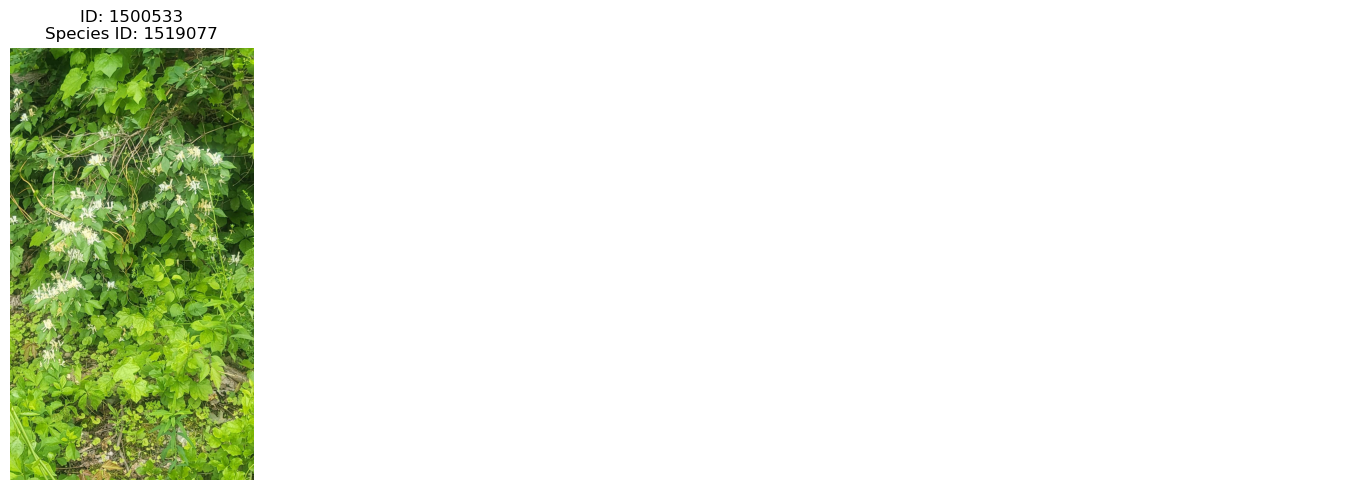


Processing presence ID: 1500518


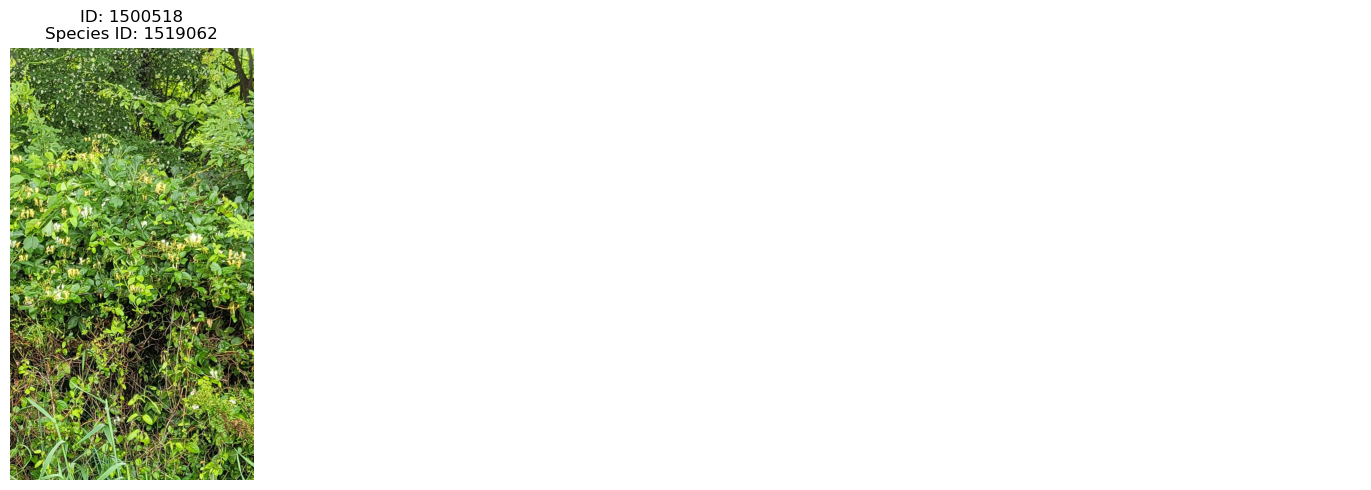


Processing presence ID: 1500517


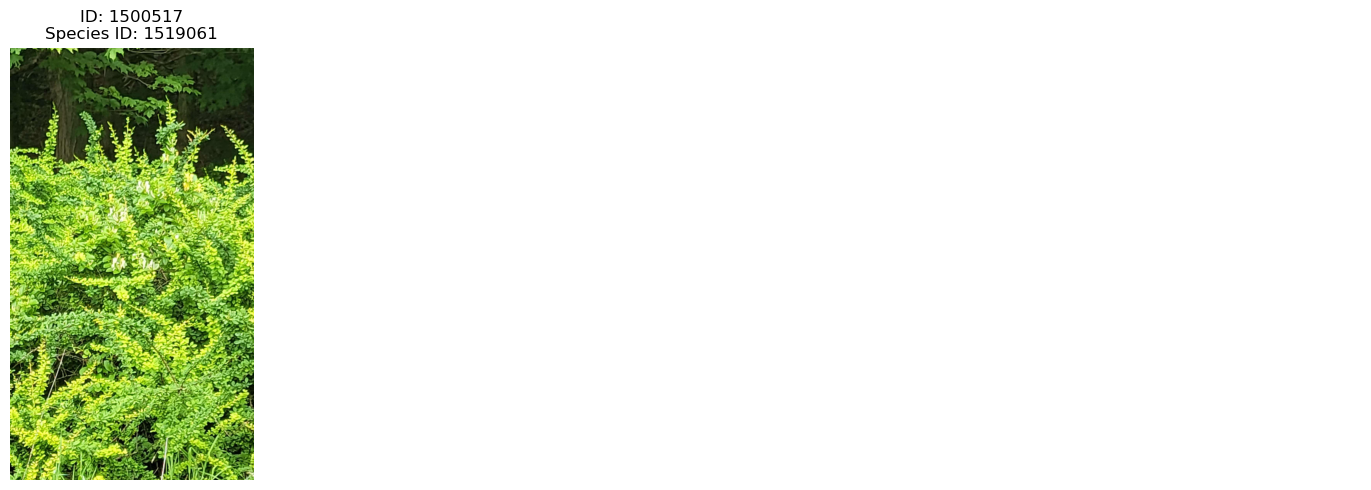


Processing presence ID: 1500499


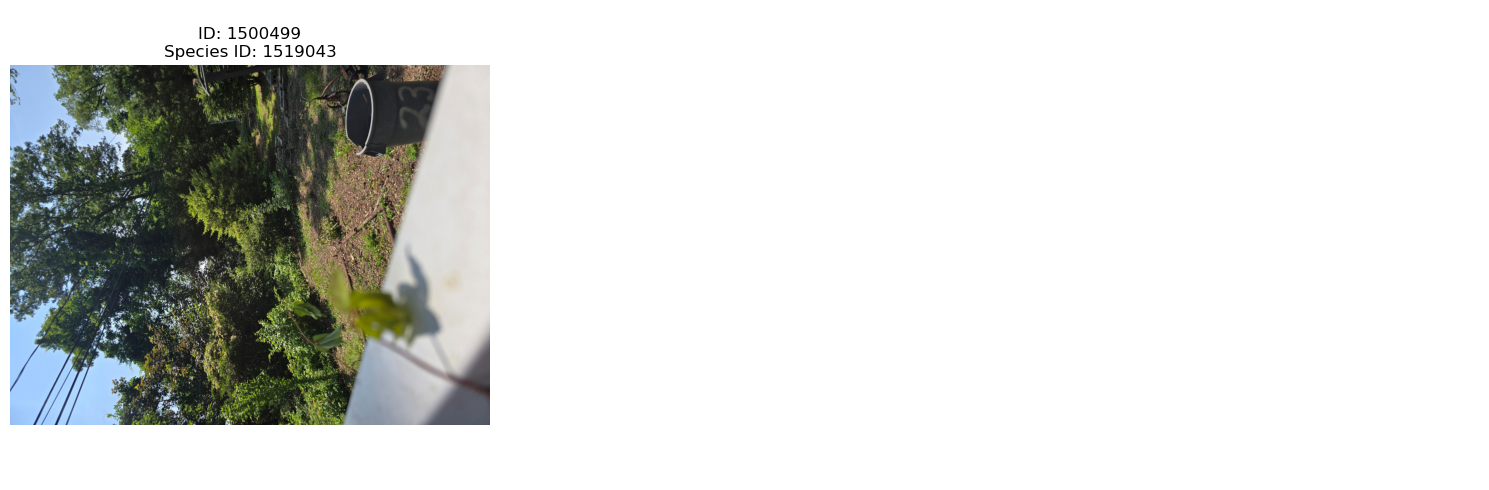


Processing presence ID: 1499995


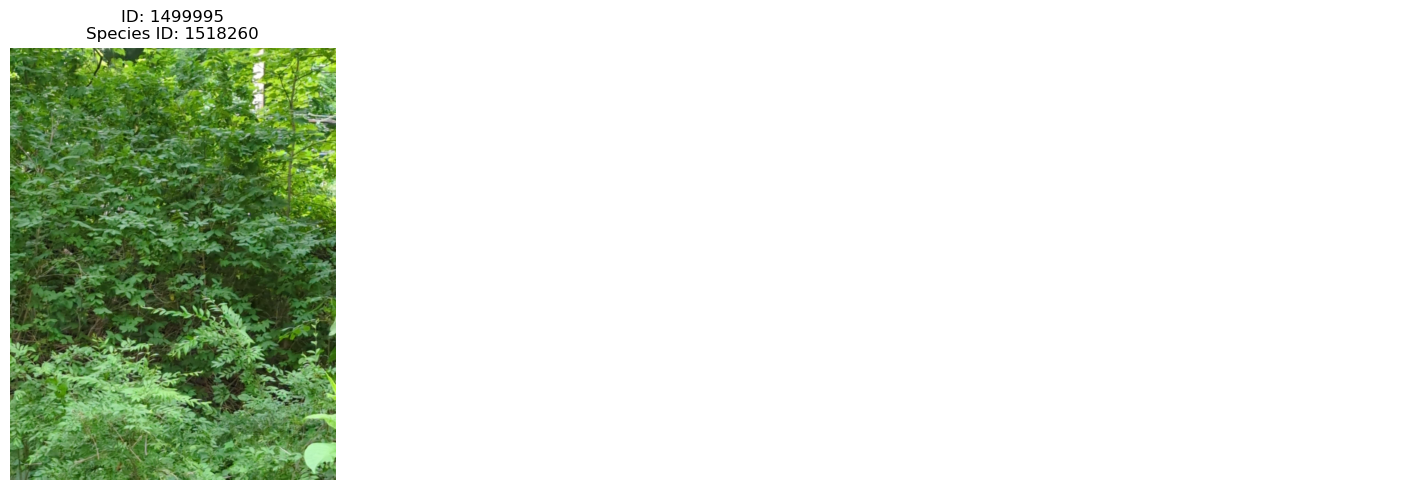


Processing presence ID: 1499994


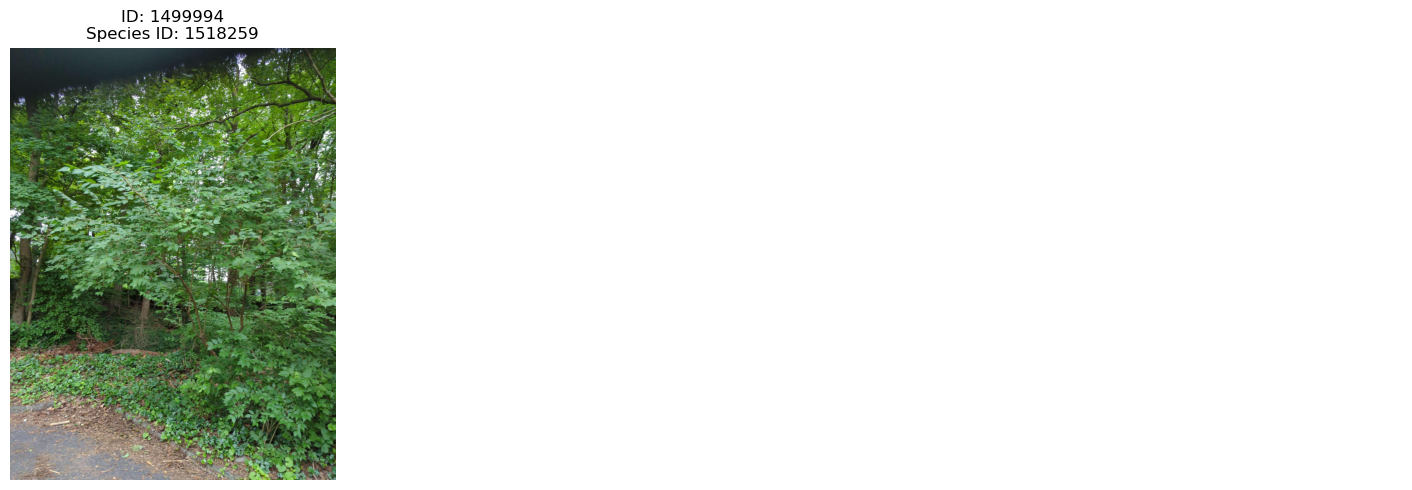


Processing presence ID: 1499373


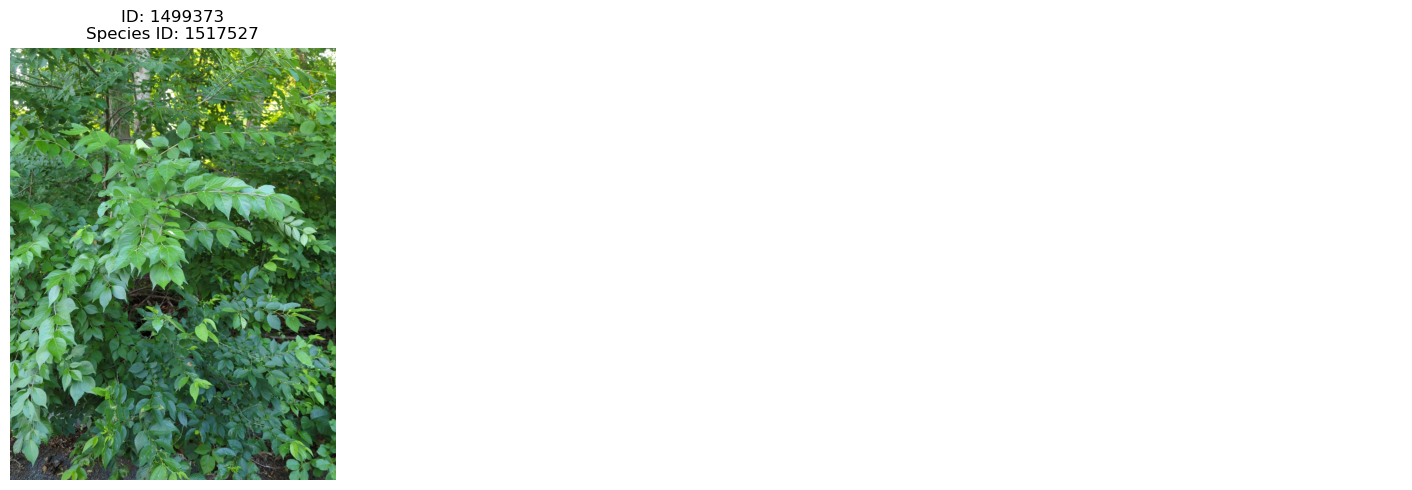


Processing presence ID: 1499371


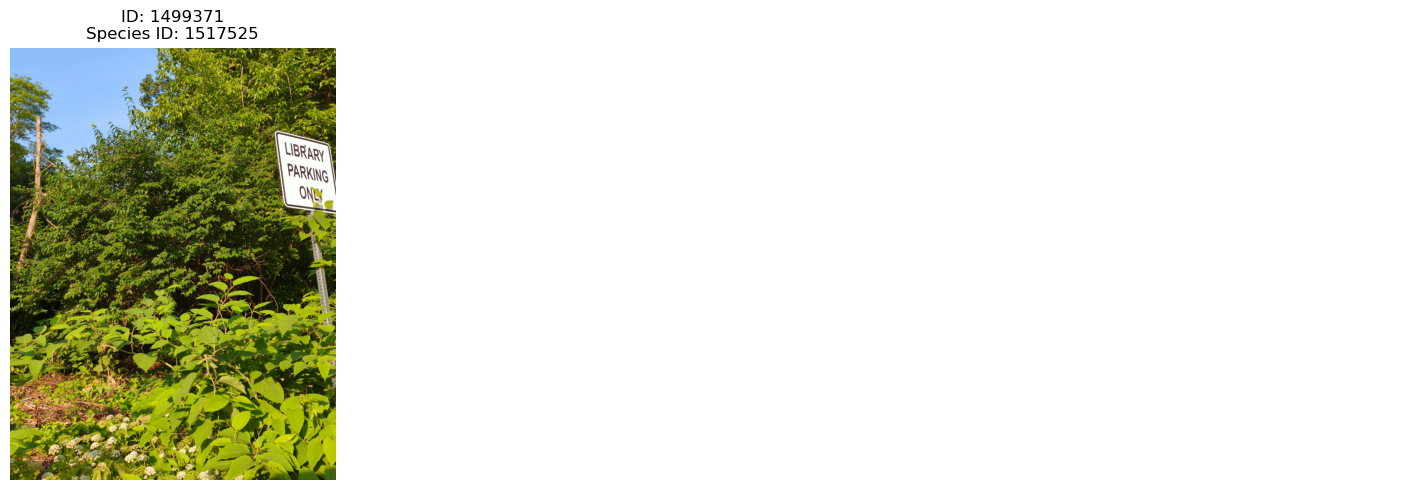


Processing presence ID: 1496820


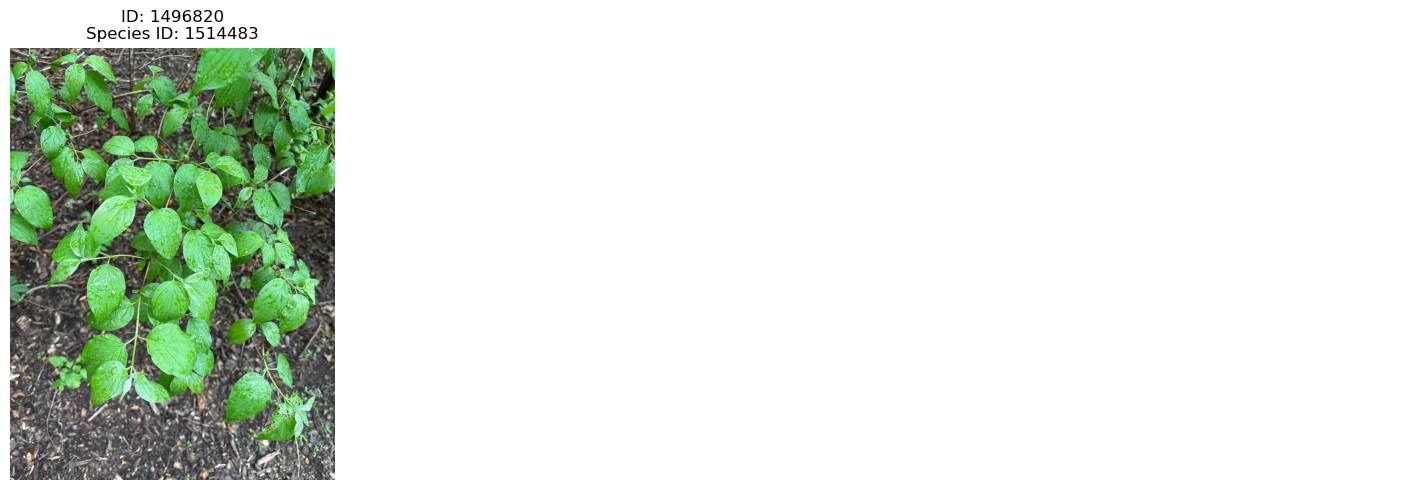


Processing presence ID: 1450909


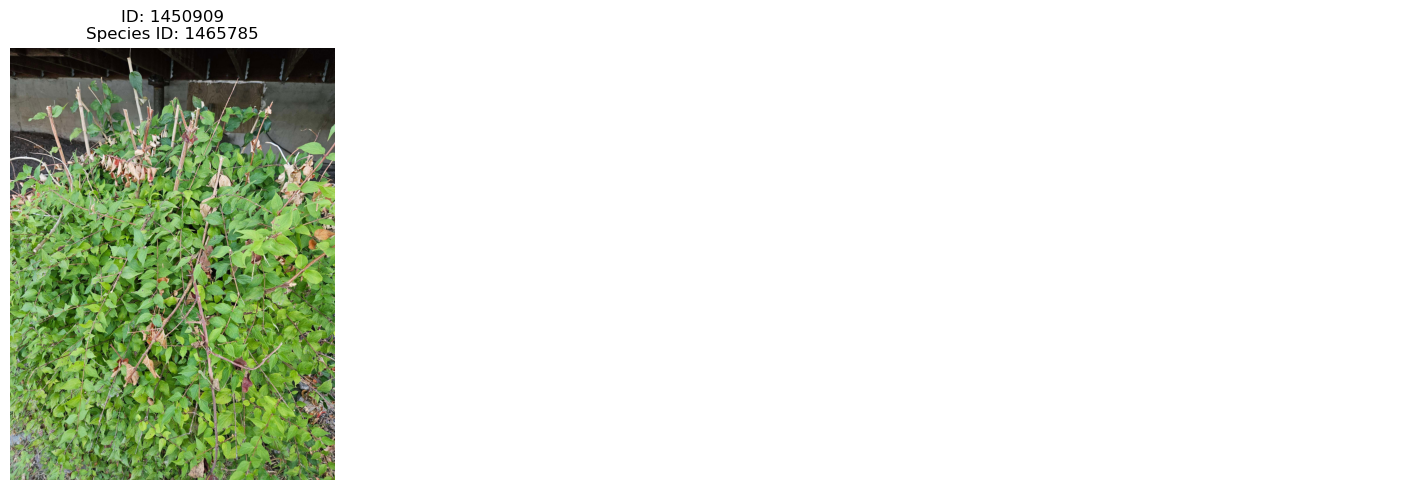

In [68]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import math

# Function to get the image from a URL, handling redirects and setting headers
def get_image_from_url(url):
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'
    }

    # Perform the GET request with headers and follow redirects
    response = iMapSession.get(url, headers=headers, allow_redirects=True)

    if response.status_code == 200:
        try:
            return Image.open(BytesIO(response.content))
        except Exception as e:
            print(f"Failed to open image. Error: {e}")
            return None
    else:
        print(f"Failed to retrieve image. Status code: {response.status_code}")
        return None

# Function to plot images for each presentSpeciesId in a grid with 3 columns
def plot_images_for_species(imap_dictionary, presence_id):
    species_list = imap_dictionary.get("speciesList", [])
    num_species = len(species_list)
    num_columns = 3
    num_rows = math.ceil(num_species / num_columns)

    fig, axs = plt.subplots(num_rows, num_columns, figsize=(15, 5 * num_rows))
    axs = axs.flatten()  # Flatten the 2D array of axes to 1D for easy iteration

    for i, species in enumerate(species_list):
        img = None

        # Check if the 'photos' list exists and has at least one item
        if "photos" in species and species["photos"]:
            photo_url = species["photos"][0].get("photoUrl", "")

            if photo_url and (photo_url.lower().endswith('.jpg') or photo_url.lower().endswith('.jpeg')):  # Ensure the URL is a valid .jpg or .jpeg
                img = get_image_from_url(photo_url)

        # Display the image if it was successfully retrieved
        if img:
            axs[i].imshow(img)
            axs[i].axis('off')  # Turn off the axis
            axs[i].set_title(f"ID: {presence_id}\nSpecies ID: {species.get('presentSpeciesId')}")
        else:
            axs[i].text(0.5, 0.5, f'ID: {presence_id}\nImage Not Available', horizontalalignment='center', verticalalignment='center')
            axs[i].axis('off')

    # Turn off remaining empty subplots
    for j in range(i + 1, num_rows * num_columns):
        axs[j].axis('off')

    plt.tight_layout()
    plt.show()

# Function to process multiple presence IDs and plot images (only first 10 records)
def plot_images_for_multiple_species_ids(presence_ids):
    base_url = "https://imapinvasives.natureserve.org/imap/services/presence/"

    # Limit to the first 10 presence IDs
    for presence_id in presence_ids[:10]:
        print(f"\nProcessing presence ID: {presence_id}")
        # Construct the full URL for each presence ID
        full_url = f"{base_url}{presence_id}"

        # Get the iMap record for this presence ID
        imap_record = iMapSession.get(full_url)

        if imap_record.status_code == 200:
            # Convert the response to a dictionary
            imap_dictionary = imap_record.json()

            # Plot images for this presence ID
            plot_images_for_species(imap_dictionary, presence_id)
        else:
            print(f"Failed to retrieve data for presence ID {presence_id}. Status code: {imap_record.status_code}")

# Process only the first 10 presence IDs and plot images
plot_images_for_multiple_species_ids(presence_ids)


# Multiple iMapInvasives records identification

### Accessing iMapInvasives API 
Create an account using https://www.imapinvasives.org/ address and use the username and password to access the iMap API
#### Use your iMap username and password in the code below to get access to the iMap API

### Species Identification using VisionAPI
#### This code saves progress incrementally by writing to the Excel file after processing each presence ID. If the script encounters an error or disconnection, it can be resumed without reprocessing the completed records.

#### Create an account in RapidAPI using the link https://rapidapi.com and subscribe to iNaturalist VisionAPI. If you don't get the VisionAPI by searching, contact the iNaturalist team. They will create an account for you.

### Use your RapidAPI key for the iNaturalist VisionAPI in the code below

In [70]:
import requests
import json
from PIL import Image
from io import BytesIO
import pandas as pd
import os
import time

# ========== Species Filter ==========
# Extract scientific names
target_species_input = Selected_species[Selected_species["CommonName"] == target_common_name]["ScientificName"].to_list()

target_species_list = [target_species_input] if isinstance(target_species_input, str) else target_species_input
# =======================

# Set the path where you will save the output file
output_file_path = r"C:\Users\tmollick\Documents\iMapML\Outputs\ML_image_recognition_iMap_output.xlsx"          # Change the working directory

# === Remove existing output file if it exists ===
if os.path.exists(output_file_path):
    os.remove(output_file_path)

# Function to extract latitude and longitude from the imap_dictionary
def get_lat_lon_from_imap(imap_dictionary):
    presence_point = imap_dictionary.get("presencePoint")
    if presence_point:
        return presence_point.get('latitude'), presence_point.get('longitude')

    presence_line = imap_dictionary.get("presenceLine")
    if presence_line:
        return presence_line.get('latitude'), presence_line.get('longitude')

    presence_polygon = imap_dictionary.get("presencePolygon")
    if presence_polygon:
        return presence_polygon.get('latitude'), presence_polygon.get('longitude')

    return None, None

# Function to reduce the image size in memory
def reduce_image_size(image, max_size_kb=700):
    exif_data = image.info.get("exif")
    quality = 95
    while True:
        buffer = BytesIO()
        if exif_data:
            image.save(buffer, "JPEG", quality=quality, exif=exif_data)
        else:
            image.save(buffer, "JPEG", quality=quality)
        if buffer.tell() <= max_size_kb * 1024 or quality <= 10:
            return buffer
        quality -= 5

# Function to identify species using iNaturalist VisionAPI
def identify_species(image_bytes, lat=None, lon=None):
    url = "https://visionapi.p.rapidapi.com/v1/rapidapi/score_image"
    headers = {
        "X-RapidAPI-Key": "fb2d499660mshffa90b4b45c3106p16583ejsnbaa19ef4277c",
        "X-RapidAPI-Host": "visionapi.p.rapidapi.com"
    }
    files = {'image': image_bytes}
    data = {'lat': lat, 'lng': lon} if lat and lon else {}
    response = requests.post(url, headers=headers, files=files, data=data)
    return response.json() if response.status_code == 200 else None

# Function to get the image from a URL, handling redirects and setting headers
def get_image_from_url(url):
    try:
        headers = {'User-Agent': 'Mozilla/5.0'}
        response = requests.get(url, headers=headers, allow_redirects=True)
        if response.status_code == 200:
            return Image.open(BytesIO(response.content))
    except Exception as e:
        print(f"Image error: {e}")
    return None

# Function to process and identify species for all presentSpeciesId
def process_species_images(imap_dictionary, base_url):
    data_rows = []
    species_list = imap_dictionary.get("speciesList", [])

    for species in species_list:
        imap_sci = species.get("nationalSpeciesList", {}).get("scientificName", "Unknown")
        if imap_sci not in target_species_list:
            continue

        try:
            photos = species.get("photos", [])
            photo_url = photos[0].get("photoUrl", "") if photos else ""
        except Exception as e:
            print(f"Skipping species in presence ID {species.get('presenceId', 'Unknown')} due to photo error: {e}")
            continue

        present_species_id = species.get("presentSpeciesId")
        presence_id = species.get("presenceId")
        imap_com = species.get("nationalSpeciesList", {}).get("commonName", "Unknown")
        imap_record_taxon = str(species.get("nationalSpeciesList", {}).get("inaturalistTaxonId", "Unknown"))

        if photo_url:
            img = get_image_from_url(photo_url)
            if img:
                resized_image_buffer = reduce_image_size(img)
                lat, lon = get_lat_lon_from_imap(imap_dictionary)
                resized_image_buffer.seek(0)
                result = identify_species(resized_image_buffer, lat, lon)
                top_result = None

                if result and "results" in result and result["results"]:
                    matched = next((r for r in result["results"] if r["taxon"]["name"] == imap_sci), None)
                    top_result = matched or max(result["results"], key=lambda x: x["original_combined_score"])

                if top_result:
                    inat_sci = top_result['taxon']['name']
                    inat_com = top_result['taxon'].get('preferred_common_name', 'Unknown').capitalize()
                    inat_taxon = str(top_result['taxon']['id'])
                    geo_score = round(top_result['original_geo_score'], 2)
                    com_score = round(top_result['original_combined_score'], 2)
                else:
                    inat_sci, inat_com, inat_taxon, geo_score, com_score = "Unknown", "Unknown", "Unknown", "Unknown", "Unknown"
            else:
                inat_sci, inat_com, inat_taxon, geo_score, com_score = "Unknown", "Unknown", "Unknown", "Unknown", "Unknown"
        else:
            photo_url = "No Photo"
            inat_sci, inat_com, inat_taxon, geo_score, com_score = "Unknown", "Unknown", "Unknown", "Unknown", "Unknown"

        # === Custom match logic ===
        honeysuckle_taxa = "honeysuckle_taxa = {" + ", ".join(f'"{x}"' for x in Selected_species[Selected_species["CommonName"] == "Honeysuckles"]["Taxon_ID"].astype(str)) + "}"
        honeysuckle_species = "honeysuckle_species = {" + ", ".join(f'"{x}"' for x in Selected_species[Selected_species["CommonName"] == "Honeysuckles"]["ScientificName"].astype(str)) + "}"
        phragmites_taxa = "phragmites_taxa = {" + ", ".join(f'"{x}"' for x in Selected_species[Selected_species["CommonName"] == "Phragmites"]["Taxon_ID"].astype(str)) + "}"
        phragmites_species = "phragmites_species = {" + ", ".join(f'"{x}"' for x in Selected_species[Selected_species["CommonName"] == "Phragmites"]["ScientificName"].astype(str)) + "}"

        if imap_record_taxon == inat_taxon:
            species_label = 1
        elif imap_sci in honeysuckle_species and inat_taxon in honeysuckle_taxa:
            species_label = 1
        elif imap_sci in phragmites_species and inat_taxon in phragmites_taxa:
            species_label = 1
        else:
            species_label = 0

        imaplink = f"https://imapinvasives.natureserve.org/imap/services/page/Presence/{presence_id}.html"
        inatlink = f"https://www.inaturalist.org/taxa/{inat_taxon}-{inat_sci.replace(' ', '-')}" if inat_taxon != "Unknown" else "Unknown"

        imaplink_formula = f'=HYPERLINK("{imaplink}", "View")'
        inatlink_formula = f'=HYPERLINK("{inatlink}", "View")' if inatlink != "Unknown" else "Unknown"
        photo_formula = f'=HYPERLINK("{photo_url}", "View")' if photo_url != "No Photo" else "No Photo"

        row = [
            None, imaplink_formula, imaplink, presence_id, present_species_id,
            photo_formula, photo_url, imap_sci, imap_com, imap_record_taxon,
            inatlink_formula, inatlink, inat_sci, inat_com, inat_taxon,
            geo_score, com_score, "", species_label, ""
        ]
        data_rows.append(row)

    return data_rows

# Process all the presence IDs
def process_multiple_species_ids(presence_ids):
    base_url = "https://imapinvasives.natureserve.org/imap/services/presence/"
    output_file = output_file_path

    if os.path.exists(output_file):
        df_existing = pd.read_excel(output_file, keep_default_na=False)
        def restore_formula(row, col, raw_col):
            val, raw = row[col], row[raw_col]
            if not isinstance(val, str) or not val.startswith("=HYPERLINK"):
                return f'=HYPERLINK("{raw}", "View")' if raw != "Unknown" and raw != "No Photo" else raw
            return val
        for col, raw_col in [("imaplink", "imaplink_raw"), ("inatlink", "inatlink_raw"), ("iMapPhoto", "iMapPhoto_raw")]:
            if col in df_existing.columns and raw_col in df_existing.columns:
                df_existing[col] = df_existing.apply(lambda r: restore_formula(r, col, raw_col), axis=1)
        processed_ids = set(df_existing["presenceId"].dropna().astype(int))
    else:
        df_existing = pd.DataFrame(columns=[
            "S.L.", "imaplink", "imaplink_raw", "presenceId", "presentSpeciesId",
            "iMapPhoto", "iMapPhoto_raw", "imap_sci", "imap_com", "imap_record_taxon",
            "inatlink", "inatlink_raw", "inat_sci", "inat_com", "inat_taxon",
            "geo_score", "com_score", "visual_model", "species_label", "com_status"
        ])
        processed_ids = set()

    for idx, presence_id in enumerate(presence_ids, start=1):
        if presence_id in processed_ids:
            print(f"Skipping already processed presence ID: {presence_id}")
            continue

        print(f"\nProcessing presence ID: {presence_id}")
        full_url = f"{base_url}{presence_id}"

        while True:
            try:
                imap_record = iMapSession.get(full_url)
                if imap_record.status_code == 200:
                    imap_dictionary = imap_record.json()
                    data_rows = process_species_images(imap_dictionary, base_url)
                    for row in data_rows:
                        row[0] = idx
                        df_existing.loc[len(df_existing)] = row
                    df_existing.to_excel(output_file, index=False)
                    processed_ids.add(presence_id)
                else:
                    print(f"Failed for presence ID {presence_id}. Status: {imap_record.status_code}")
                break
            except requests.exceptions.RequestException as e:
                print(f"Network error: {e}. Retrying...")
                time.sleep(5)
            except Exception as e:
                print(f"Unexpected error: {e}. Saving and exiting.")
                df_existing.to_excel(output_file, index=False)
                return

# Replace presence_ids with your actual list of IDs
process_multiple_species_ids(presence_ids)


Processing presence ID: 1500533

Processing presence ID: 1500518

Processing presence ID: 1500517

Processing presence ID: 1500499

Processing presence ID: 1499995

Processing presence ID: 1499994

Processing presence ID: 1499373

Processing presence ID: 1499371

Processing presence ID: 1496820

Processing presence ID: 1450909

Processing presence ID: 1444414

Processing presence ID: 1444411

Processing presence ID: 1444262

Processing presence ID: 1441354

Processing presence ID: 1441353

Processing presence ID: 1441352

Processing presence ID: 1438387

Processing presence ID: 1413884

Processing presence ID: 1412607

Processing presence ID: 1412606

Processing presence ID: 1412166

Processing presence ID: 1411492

Processing presence ID: 1411491

Processing presence ID: 1411490

Processing presence ID: 1411488

Processing presence ID: 1411487

Processing presence ID: 1411486

Processing presence ID: 1411485

Processing presence ID: 1411484

Processing presence ID: 1411483

Processin

### Apply threshold values to the output file from iNaturalist
### The invasive species Tier can be accessed through the url https://www.nynhp.org/invasives/species-tiers-table/

In [73]:
# conda install lxml # Run this command if it creates a problem opening the table

# URL of the table
url = "https://www.nynhp.org/invasives/species-tiers-table/"

# Read all tables on the page
tables = pd.read_html(url)

# Check how many tables were found
print(f"Total tables found: {len(tables)}")

# View the first table (adjust index if needed)
df2 = tables[0]

# Replace MultiIndex with only the lower-level column names
df2.columns = df2.columns.get_level_values(1)

# Rename 'NYS' column to 'NYS_Tier'
df2.rename(columns={'NYS': 'NYS_Tier'}, inplace=True)

df2.head()

Total tables found: 1


,Common Name,Scientific Name,Type,Ecological,Socio-Economic,NYS Part 575,NYS_Tier,APIPP,Capital Region,CRISP,Finger Lakes,Lower Hudson,LIISMA,SLELO,WNY
0,African clawed frog,Xenopus laevis,AA,Moderate,Insignificant Positive,Regulated,NaN,NaN,NaN,NaN,NaN,M,NaN,NaN,NaN
1,African elodea,Lagarosiphon major,AP,High,Low Negative,NaN,1b,NaN,NaN,NaN,NaN,1c,NaN,NaN,NaN
2,Africanized honey bee,"Apis mellifera scutellata x A. m. ligustica, A...",TA,Not assessed,Not assessed,Prohibited,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN
3,Agrilus sp. 9895,Agrilus sp. 9895,TA,Not assessed,Not assessed,NaN,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Alewife,Alosa pseudoharengus,AA,Moderate,Insignificant Negative,NaN,NaN,NaN,2,NaN,4,NaN,NaN,NaN,4


### Added thredhold and Geo Score

In [76]:
default_threshold = 77.62 # Beyond the 14 selected species
default_geo_score = 33.24 # Beyond the 14 selected species

# Create the threshold_values dictionary
threshold_values = dict(zip(
    Selected_species["ScientificName"],
    Selected_species["Combined_score_threshold"]
))

# Create the Geo_score_mean dictionary
Geo_score_mean = dict(zip(
    Selected_species["ScientificName"],
    Selected_species["Geo_score_mean"]
))

### Generate the final output by applying threshold combined score and mean geo score as well as the NYS invasive species Tier

In [79]:
from openpyxl import load_workbook, Workbook

# Define file paths
input_file = r"C:\Users\tmollick\Documents\iMapML\Outputs\ML_image_recognition_iMap_output.xlsx"    # Replace with your desired input file here
output_file = r"C:\Users\tmollick\Documents\iMapML\Outputs\Final_ML_image_recognition_iMap_output_with_thresholds.xlsx"  # Rename the output file to save to your location

# Load the original Excel file using OpenPyXL and Pandas
wb = load_workbook(input_file, data_only=False)
ws = wb.active
df = pd.read_excel(input_file, engine="openpyxl")


# Convert columns to numeric where necessary
df["com_score"] = pd.to_numeric(df["com_score"], errors="coerce")
df["geo_score"] = pd.to_numeric(df["geo_score"], errors="coerce")


# Merge df with df2 to get the NYS_Tier info
df = df.merge(df2[['Scientific Name', 'NYS_Tier']], how='left', left_on='imap_sci', right_on='Scientific Name')

# Assign thresholds
df["Species_selected_threshold"] = df["imap_sci"].apply(lambda x: threshold_values.get(x, default_threshold))
df["Geo_score_mean"] = df["imap_sci"].apply(lambda x: Geo_score_mean.get(x, default_geo_score))

# Check com_score status (applies to everyone)
df["Com_score_above_or_below"] = df.apply(
    lambda row: "Above" if row["com_score"] >= row["Species_selected_threshold"] else "Below", axis=1
)

# Check geo_score status
df["Geo_score_above_or_below"] = df.apply(
    lambda row: "Above" if row["geo_score"] >= row["Geo_score_mean"] else "Below", axis=1
)

# Apply exception rule based on 'species_label'
df["com_status"] = df["species_label"].apply(lambda x: "Match" if x == 1 else "Unmatch")

# Default value for Recommended_status
df["Recommended_status"] = "Manual review"

# Clean up NYS_Tier values (no conversion to numeric because there are non-numeric tiers like 1a, 1b, etc.)
df["NYS_Tier"] = df["NYS_Tier"].astype(str).str.strip()

# Define the tiers where geo_score applies
tiers_with_geo_score = ['1a', '1b', '1c', '1', '2', '3']

# Condition for Tiers 1a, 1b, 1c, 1, 2, 3 -> apply com_score + geo_score + match
tier_1_to_3_condition = (
    (df["NYS_Tier"].isin(tiers_with_geo_score)) &
    (df["com_score"] >= df["Species_selected_threshold"]) &
    (df["geo_score"] >= df["Geo_score_mean"]) &
    (df["com_status"] == "Match")
)

# Condition for Tier 4 and blanks -> apply com_score + match only
tier_4_or_blank_condition = (
    (~df["NYS_Tier"].isin(tiers_with_geo_score)) &
    (df["com_score"] >= df["Species_selected_threshold"]) &
    (df["com_status"] == "Match")
)

# Apply conditions
df.loc[tier_1_to_3_condition | tier_4_or_blank_condition, "Recommended_status"] = "Automatically confirmed"

# Drop 'Scientific Name' and any other unnecessary columns before export
df.drop(columns=["Scientific Name", "visual_model"], inplace=True, errors='ignore')

# Preserve hyperlinks using `values_only=False`
hyperlink_columns = ["imaplink", "iMapPhoto", "inatlink"]

# Create a new workbook for writing
wb_new = Workbook()
ws_new = wb_new.active
ws_new.title = "Processed Data"

# Copy headers (Include both original and new columns)
headers = list(df.columns)
ws_new.append(headers)

# Loop through rows and copy data while preserving hyperlinks
for row_idx, row in enumerate(ws.iter_rows(values_only=False), start=1):
    if row_idx == 1:  # Skip header row (already written)
        continue

    new_row = []
    row_data = {}

    for col_idx, cell in enumerate(row, start=1):
        column_name = ws.cell(row=1, column=col_idx).value

        # Skip columns we dropped earlier
        if column_name in ["Scientific Name", "visual_model"]:
            continue

        if cell.hyperlink:
            new_cell = ws_new.cell(row=row_idx, column=col_idx)
            new_cell.value = cell.value
            new_cell.hyperlink = cell.hyperlink.target
            new_cell.style = "Hyperlink"
        else:
            row_data[column_name] = cell.value

    # Add the data from Pandas DataFrame
    for col_name in [
        "Species_selected_threshold", "Com_score_above_or_below", "Geo_score_mean",
        "Geo_score_above_or_below", "Recommended_status", "com_status", "NYS_Tier"
    ]:
        row_data[col_name] = df.at[row_idx - 2, col_name]

    # Ensure the new row is in the correct order (excluding dropped columns)
    new_row = [row_data.get(col, None) for col in headers]

    ws_new.append(new_row)

# Base output file name
base_output_file = r"C:\Users\tmollick\Documents\iMapML\Outputs\Final_ML_image_recognition_iMap_output_with_thresholds"
output_file = base_output_file + ".xlsx"

# Increment filename if it exists
counter = 1
while os.path.exists(output_file):
    output_file = f"{base_output_file}_{counter}.xlsx"
    counter += 1

# Save the final workbook
wb_new.save(output_file)

print(f"Processing complete. File saved at: {output_file}.")

Processing complete. File saved at: C:\Users\tmollick\Documents\iMapML\Outputs\Final_ML_image_recognition_iMap_output_with_thresholds_1.xlsx.
